# Train plant diseases detection

## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train', # directory 
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 69768 files belonging to 38 classes.


In [3]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [4]:
# x, y 
for x, y in training_set:
    print("x : " , x , x.shape)
    print("y : " , y , y.shape)
    break

    # x: images: 
    # shape=(32, 128, 128, 3), dtype=float32) (32, 128, 128, 3)
    # y : Classes: 
    # shape=(32, 38), dtype=float32) (32, 38)

x :  tf.Tensor(
[[[[ 90.    83.    90.  ]
   [ 81.    74.    81.  ]
   [ 34.25  29.25  35.25]
   ...
   [113.75 108.75 112.75]
   [111.75 106.75 110.75]
   [117.25 112.25 116.25]]

  [[ 98.75  91.75  98.75]
   [ 96.5   90.    96.75]
   [ 87.5   82.5   88.5 ]
   ...
   [117.5  112.5  116.5 ]
   [116.   111.   115.  ]
   [122.   117.   121.  ]]

  [[106.   101.   107.  ]
   [ 87.    82.    88.  ]
   [ 83.25  80.5   85.75]
   ...
   [119.25 114.25 118.25]
   [112.25 107.25 111.25]
   [109.25 104.25 108.25]]

  ...

  [[152.5  151.5  159.5 ]
   [152.25 151.25 159.25]
   [149.5  148.5  156.5 ]
   ...
   [164.75 163.75 171.75]
   [166.5  165.5  173.5 ]
   [168.5  167.5  175.5 ]]

  [[134.   133.   141.  ]
   [138.5  137.5  145.5 ]
   [143.25 142.25 150.25]
   ...
   [160.5  159.5  167.5 ]
   [160.25 159.25 167.25]
   [161.25 160.25 168.25]]

  [[136.25 135.25 143.25]
   [141.75 140.75 148.75]
   [150.25 149.25 157.25]
   ...
   [160.75 159.75 167.75]
   [163.25 162.25 170.25]
   [166.   165.

### Validation Image Preprocessing

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid', # directory 
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17452 files belonging to 38 classes.


In [6]:
validation_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

## Building Model

In [7]:
# from tensorflow.keras.layers import Dense,Conv2D, MaxPool2D, Flatten
# from tensorflow.keras.models import Sequential

In [8]:
layers = tf.keras.layers

In [9]:
cnn = tf.keras.models.Sequential()

In [10]:
cnn.add(layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

C:\Users\HP\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.add(layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [12]:
cnn.add(layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
cnn.add(layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
cnn.add(layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu')) # adding more conv layers to avoid underfitting
cnn.add(layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(layers.MaxPool2D(pool_size=2,strides=2))

In [15]:
cnn.add(layers.Dropout(0.25)) # To avoid overfitting

In [16]:
cnn.add(layers.Flatten())

In [17]:
# Hidden Layer to feed fully connected layers
cnn.add(layers.Dense(units=1500, activation = 'relu')) # change number of units from 1024 to 1500 to avoid underfitting

In [18]:
cnn.add(layers.Dropout(0.40)) # To avoid overfitting

In [19]:
# Output Layer: 38 as we have 38 class
cnn.add(layers.Dense(units=38, activation = 'softmax'))

### Compiling the Model

In [20]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss="categorical_crossentropy", metrics=['accuracy']) # add low learning rate to avoid overshooting problem

In [21]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [58]:
training_history = cnn.fit(x= training_set, validation_data= validation_set, epochs= 10)

Epoch 1/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3145s 1s/step - accuracy: 0.4222 - loss: 1.9404 - val_accuracy: 0.6031 - val_loss: 1.2609
Epoch 2/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3252s 1s/step - accuracy: 0.7013 - loss: 0.9291 - val_accuracy: 0.7311 - val_loss: 0.8374
Epoch 3/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 3050s 1s/step - accuracy: 0.7830 - loss: 0.6652 - val_accuracy: 0.7737 - val_loss: 0.7184
Epoch 4/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2719s 1s/step - accuracy: 0.8269 - loss: 0.5193 - val_accuracy: 0.8012 - val_loss: 0.6249
Epoch 5/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2593s 1s/step - accuracy: 0.8529 - loss: 0.4337 - val_accuracy: 0.8205 - val_loss: 0.5654
Epoch 6/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2806s 1s/step - accuracy: 0.8716 - loss: 0.3802 - val_accuracy: 0.8133 - val_loss: 0.6275
Epoch 7/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2820s 1s/step - accuracy: 0.8844 - loss: 0.3448 - val_accuracy: 0.8322 - val_loss: 0.5495
Epoch 8/10
2181/2181 ━━━━━━━━━━━━━━━━━━━━ 2624s 1s/step - accuracy: 0.8910 -

## Evaluating Model

In [43]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2181/2181 ━━━━━━━━━━━━━━━━━━━━ 1028s 471ms/step - accuracy: 0.9104 - loss: 0.2645
Training accuracy: 0.9104317426681519


In [44]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

546/546 ━━━━━━━━━━━━━━━━━━━━ 183s 334ms/step - accuracy: 0.8381 - loss: 0.5830
Validation accuracy: 0.8380701541900635


## Saving Model 

In [64]:
cnn.save('trained_plant_disease_model.h5')

In [65]:
cnn.save('trained_plant_disease_model.keras') # compressed and less file size

In [66]:
#Return Dictionary of history
training_history.history 

{'accuracy': [0.42224228382110596,
  0.7012957334518433,
  0.7829663753509521,
  0.8269407153129578,
  0.8529268503189087,
  0.8716460466384888,
  0.8843739032745361,
  0.8910245299339294,
  0.9007998108863831,
  0.9050854444503784],
 'loss': [1.9403908252716064,
  0.9291113615036011,
  0.6651951670646667,
  0.5193108916282654,
  0.4337112307548523,
  0.38024407625198364,
  0.344814270734787,
  0.32146674394607544,
  0.2952530086040497,
  0.27722468972206116],
 'val_accuracy': [0.6030827164649963,
  0.7311483025550842,
  0.773722231388092,
  0.8011689186096191,
  0.8204790353775024,
  0.8133165240287781,
  0.8322255611419678,
  0.8466651439666748,
  0.8486133217811584,
  0.8380701541900635],
 'val_loss': [1.2609496116638184,
  0.837435781955719,
  0.718441367149353,
  0.6248995065689087,
  0.5654121041297913,
  0.6275319457054138,
  0.5495086908340454,
  0.5164733529090881,
  0.5039554834365845,
  0.5829619765281677]}

In [67]:
# Recording Training History in json
import json
with open('training_history.json','w') as f:
  json.dump(training_history.history,f)

In [68]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

In [25]:
epochs = [i for i in range(1,11)]
print(epochs)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


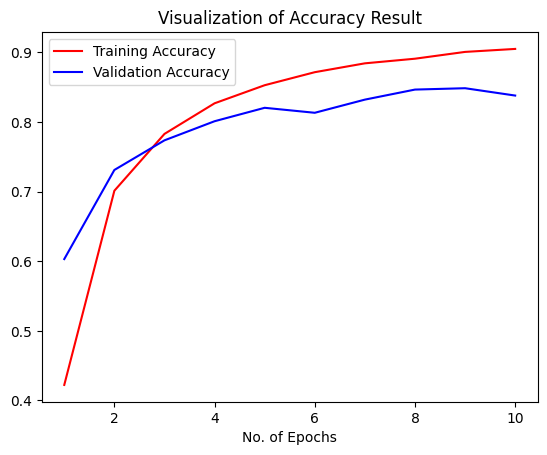

In [70]:
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Using the Saved Model

In [60]:
from tensorflow.keras.models import load_model

# cnn = load_model('trained_plant_disease_model.keras')
cnn = load_model('trained_plant_disease_model.keras',  compile=False)

## Other Mertics: 

In [61]:
class_name = validation_set.class_names
print(class_name)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [62]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17452 files belonging to 38 classes.


In [63]:
y_pred = cnn.predict(test_set)


17452/17452 ━━━━━━━━━━━━━━━━━━━━ 839s 48ms/step


In [64]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17452,))>

In [65]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17452, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17452, 38), dtype=float32)>

In [66]:
y_true = tf.argmax(true_categories, axis=1)
y_true

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17452,))>

In [67]:
predicted_categories

<tf.Tensor: shape=(17452,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17452,))>

In [68]:
# y_true = tf.squeeze(true_categories).numpy().astype(int)
# y_true

In [35]:
!pip install scikit-learn

In [69]:
from sklearn.metrics import confusion_matrix,classification_report

In [70]:
# Precision Recall Fscore
print(classification_report(y_true,predicted_categories,target_names=class_name,zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.64      0.87      0.74       504
                                 Apple___Black_rot       0.92      0.93      0.93       497
                          Apple___Cedar_apple_rust       0.88      0.82      0.85       440
                                   Apple___healthy       0.81      0.81      0.81       502
                               Blueberry___healthy       0.90      0.90      0.90       454
          Cherry_(including_sour)___Powdery_mildew       0.92      0.91      0.91       421
                 Cherry_(including_sour)___healthy       0.91      0.98      0.95       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.68      0.73       290
                       Corn_(maize)___Common_rust_       0.97      0.97      0.97       477
               Corn_(maize)___Northern_Leaf_Blight       0.82      0.90      0.

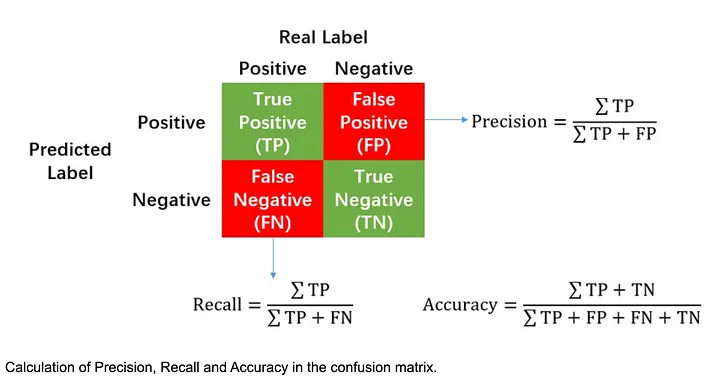

### Confusion Matrix Visualization

In [71]:
cm = confusion_matrix(y_true,predicted_categories)
cm

array([[440,   5,   1, ...,   0,   0,   0],
       [ 19, 464,   0, ...,   0,   0,   0],
       [ 22,   3, 362, ...,   0,   4,   0],
       ...,
       [  3,   0,   2, ..., 368,   6,   5],
       [  0,   0,   0, ...,   0, 411,   2],
       [  7,   0,   6, ...,   0,   3, 407]], shape=(38, 38))

In [72]:
cm.shape

(38, 38)

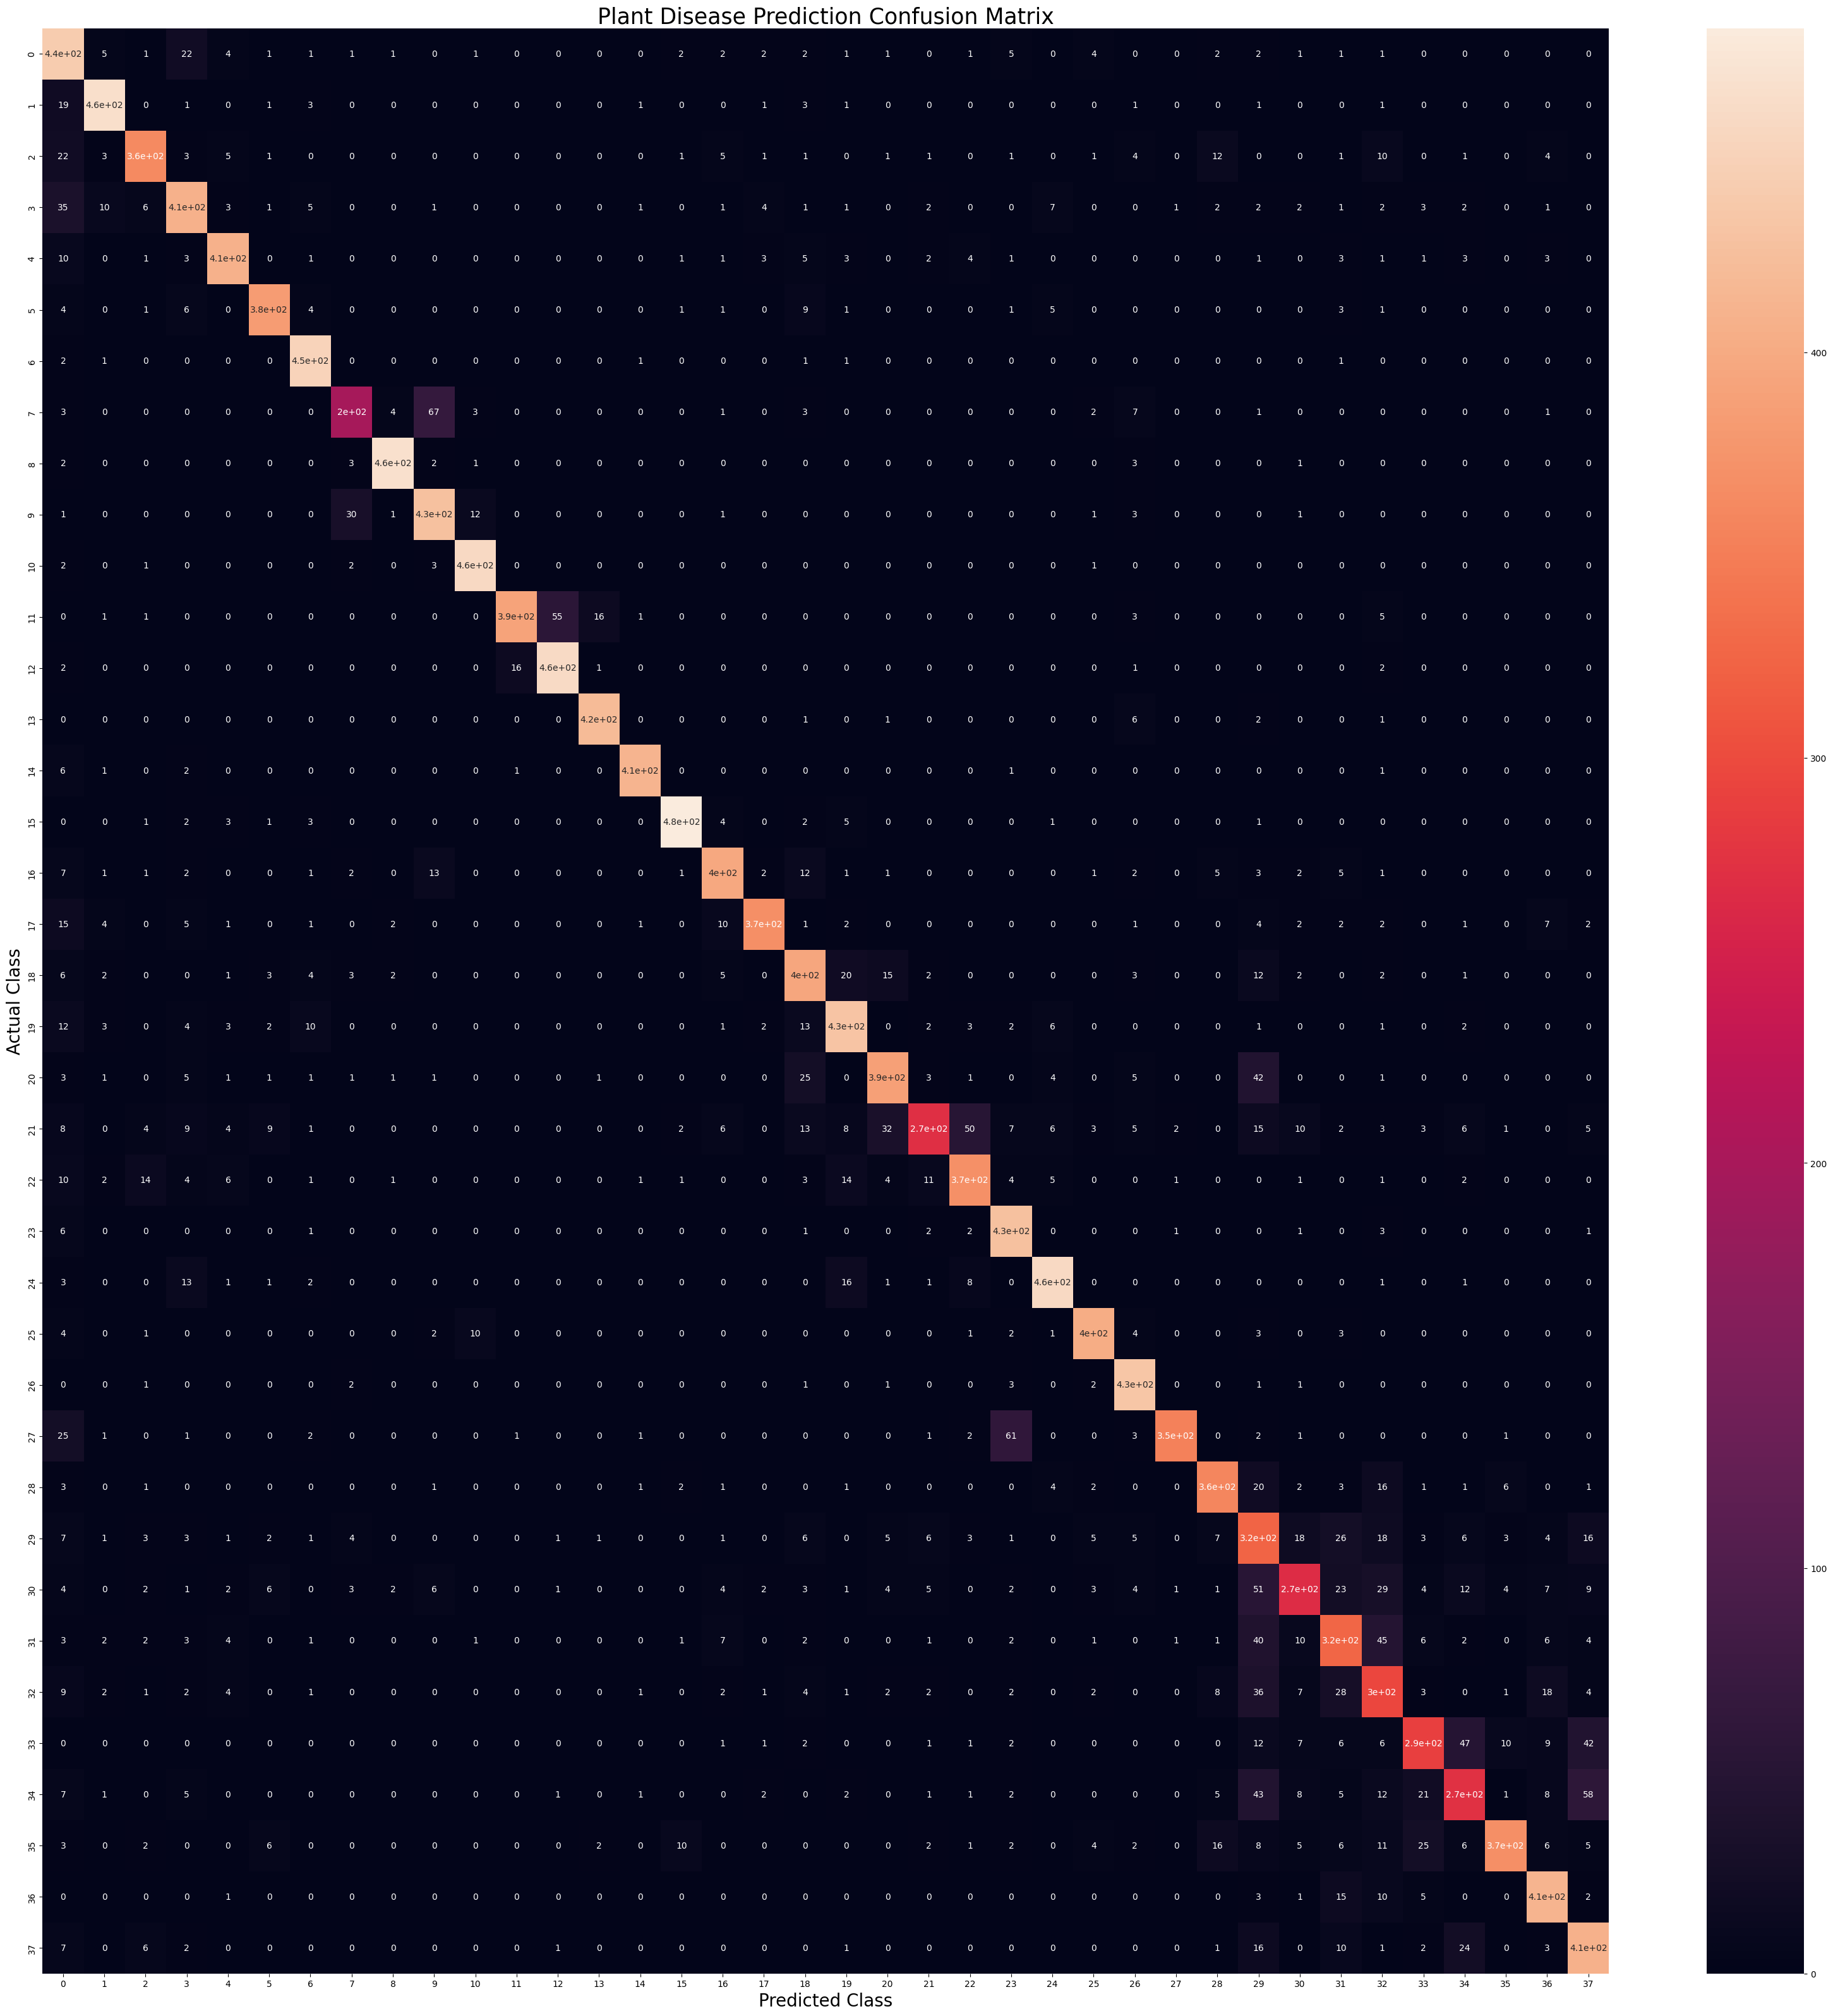

In [73]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()